In [1]:
from sqlalchemy import create_engine
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import skew
import seaborn as sns

engine = create_engine("mysql+pymysql://root:@127.0.0.1/used_car_sales_db")

In [2]:
# Def Functions

# Gets ratio of price / mmr
def get_ratio_status(price, mmr, low=0.1, high=5):
    if pd.isna(price) or pd.isna(mmr) or mmr == 0:
        return np.nan, "invalid"

    ratio = price / mmr

    if ratio < low:
        return ratio, "too_low"
    elif ratio > high:
        return ratio, "too_high"
    else:
        return ratio, "normal"
    
# Removes characters and capitalizes certain letters in "seller" column
def clean_sellers(df):
    df["seller"] = (
        df["seller"]
        .str.lower()
        .str.replace("-", " ", regex=False)
        .str.strip()
    )
    df["seller"] = df["seller"].str.title()
    df["seller"] = df["seller"].apply(
        lambda x: " ".join(
            word.upper() if word.lower() in ["llc", "lt", "tdaf", "ge", "sc", "la", "aq", "rd", "dt"] else word
            for word in str(x).split()
        )
    )
    return df

# Categorizes vehicle condition
def categorize_condition(df):
    bins = [0, 10, 20, 30, 40, 50]
    labels = ["Poor", "Below Average", "Average", "Good", "Excellent"]
    df["condition_categorized"] = pd.cut(df["vehicle_condition"], bins = bins, labels = labels)
    return df

# Classifies vehicle bodies
def classify_body(x):
    x = str(x).lower()
    
    if x.strip() == "" or x == "nan":
        return "Others"
    if x == "suv":
        return x.upper()
    if any(k in x for k in ["sedan", "navigation"]):
        return "Sedan"
    if any(k in x for k in ["coupe", "koup"]):
        return "Coupe"
    if any(k in x for k in ["cab", "supercrew"]):
        return "Pickup Truck"
    if "van" in x:
        return "Van"
    if "wagon" in x:
        return "Wagon"
    if "convertible" in x:
        return "Convertible"
    
    return x.title()

# Classifies vehicle makers
def classify_make(y):
    y = str(y).lower()
    
    if y.strip() == "" or y == "nan":
        return "Unknown"
    if "dodge" in y:
        return "Dodge"
    if "mazda" in y:
        return "Mazda"
    if "hyundai" in y:
        return "Hyundai"
    if "chev" in y:
        return "Chevrolet"
    if "gmc" in y:
        return "GMC"
    if "land" in y:
        return "Land Rover"
    if "mercedes" in y:
        return "Mercedes-Benz"
    if "vw" in y:
        return "Volkswagen"
    
    return y.title()
    

In [3]:
# How many vehicles were sold?

query = '''
SELECT COUNT(*) as sales_count
FROM car_sales;
'''

df = pd.read_sql(query, engine)

# Data Cleaning
df["sales_count"] = df["sales_count"].apply(lambda x: f"{x:,}")

df

,sales_count
0,"550,298"


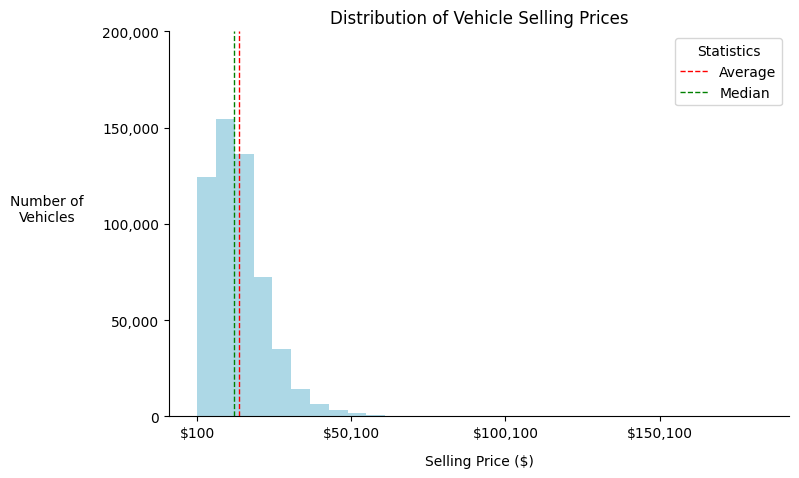

,metric,value
0,Average,"$13,611.22"
1,Median,"$12,100.00"
2,Standard Deviation,"$9,744.66"
3,Lowest Price,$100.00
4,Highest Price,"$183,000.00"
5,Skewness,1.94 (Right Skew)


In [ ]:
# Q. What is the distribution of vehicle selling prices?

query = '''
SELECT sellingprice, mmr
FROM car_sales 
WHERE sellingprice IS NOT NULL
'''

df = pd.read_sql(query, engine)

# Data Exclusion
df[["ratio", "status"]] = df.apply(
    lambda x: get_ratio_status(x["sellingprice"], x["mmr"]),
    axis = 1,
    result_type = "expand"
)
cleaned_df = df[~df["status"].isin(["too_high", "too_low", "invalid"])]

# Calculation
min_price = cleaned_df["sellingprice"].min()
max_price = cleaned_df["sellingprice"].max()
avg_price = cleaned_df["sellingprice"].mean()
med_price = cleaned_df["sellingprice"].median()
std_price = cleaned_df["sellingprice"].std()
skewness = skew(cleaned_df["sellingprice"])

# Visualization
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(
    cleaned_df["sellingprice"],
    bins = 30,
    color = "lightblue"
    )
ax.set_title("Distribution of Vehicle Selling Prices")
ax.set_xlabel(
    "Selling Price ($)",
    labelpad = 10
    )
ax.set_ylabel(
    "Number of\nVehicles",
    rotation = 0,
    labelpad = 40
    )
x_ticks = range(min_price, max_price, 50000)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"${x_t:,}" for x_t in x_ticks])
y_ticks = range(0, max_price + 50000, 50000)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{y_t:,}" for y_t in y_ticks])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.axvline(
    avg_price,
    label = "Average", 
    color = "red",
    linestyle = "dashed", 
    linewidth = 1
    )
ax.axvline(
    med_price,
    label = "Median",
    color = "green",
    linestyle = "dashed", 
    linewidth = 1
    )
ax.legend(title = "Statistics")

# Results
plt.show()

summary = pd.DataFrame({
    "metric": ["Average", "Median", "Standard Deviation", "Lowest Price", "Highest Price", "Skewness"],
    "value": [avg_price, med_price, std_price, min_price, max_price, skewness]
})
def format_value(metric, value):
    if metric == "Skewness":
        label = "Right Skew" if value > 0 else "Left Skew" if value < 0 else "Symmetric"
        return f"{value:,.2f} ({label})"
    else:
        return f"${value:,.2f}"
summary["value"] = [format_value(m, v) for m, v in zip(summary["metric"], summary["value"])]

summary

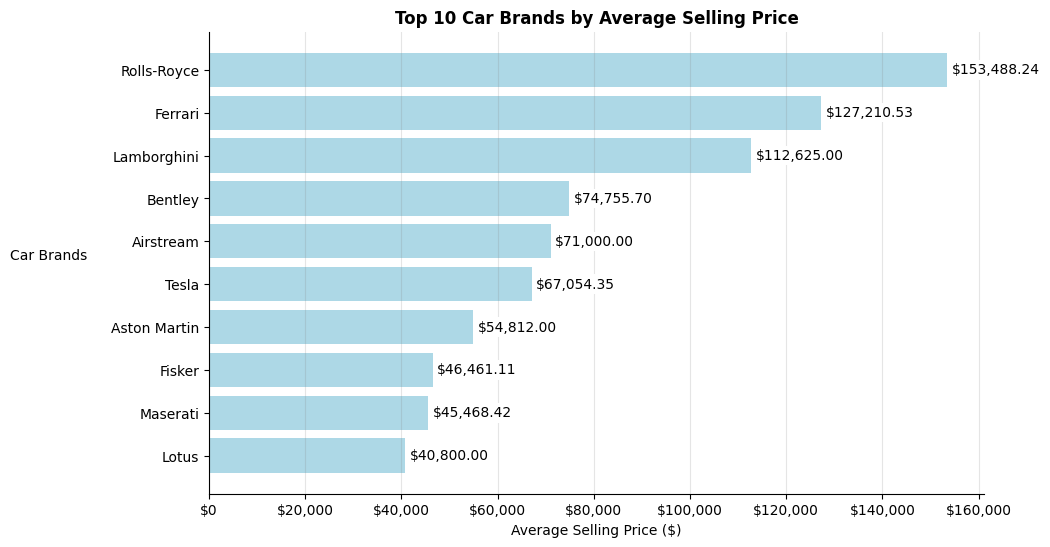

In [5]:
# Q. Which car brands have the highest average selling prices?

query = '''
SELECT 
    CASE 
        WHEN make LIKE 'ford%%' THEN 'Ford'
        WHEN make LIKE 'dodge%%' THEN 'Dodge'
        WHEN make LIKE 'mazda%%' THEN 'Mazda'
        WHEN make LIKE 'hyundai%%' THEN 'Hyundai'
        WHEN make LIKE 'chev%%' THEN 'Chevrolet'
        WHEN make LIKE 'gmc%%' THEN 'GMC'
        WHEN make LIKE 'land%%' THEN 'Land Rover'
        WHEN make LIKE 'mercedes%%' THEN 'Mercedes-Benz'
        WHEN make LIKE 'vw%%' THEN 'Volkswagen'
        ELSE make
    END AS brand,
    ROUND(AVG(sellingprice), 2) AS avg_selling_price,
    mmr
FROM car_sales
GROUP BY brand
ORDER BY avg_selling_price DESC
'''

df = pd.read_sql(query, engine)

# Data Exclusion
df[["ratio", "status"]] = df.apply(
    lambda x: get_ratio_status(x["avg_selling_price"], x["mmr"]),
    axis=1,
    result_type="expand"
)
cleaned_df = df[~df["status"].isin(["too_high", "too_low", "invalid"])]

df_top = df.head(10)

# Cleaning & Formatting
df_top = df_top[df_top["brand"].str.strip() != ""]
df_top["brand"] = df_top["brand"].apply(lambda x: x if x[0].isupper() else x.capitalize())

# Visualization
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(
    df_top["brand"],
    df_top["avg_selling_price"],
    color = "lightblue"
)
for bar, price in zip(bars, df_top["avg_selling_price"]):
    ax.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height()/2,
        f"${price:,.2f}",
        va = "center",
        bbox = dict(
            facecolor="white", 
            edgecolor = "none", 
            pad = 2
            )
        )
ax.grid(
    axis = "x",
    color = "gray",
    linestyle = "-",
    alpha = .2
)
ax.set_title(
    "Top 10 Car Brands by Average Selling Price",
    fontweight = "bold"
    )
ax.set_xlabel("Average Selling Price ($)")
ax.set_ylabel(
    "Car Brands",
    rotation = 0,
    labelpad = 45
    )
ticks = range(0, int(df_top["avg_selling_price"].max() + 20000), 20000)
ax.set_xticks(ticks)
ax.set_xticklabels([f"${t:,.0f}" for t in ticks])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.invert_yaxis()
plt.show()

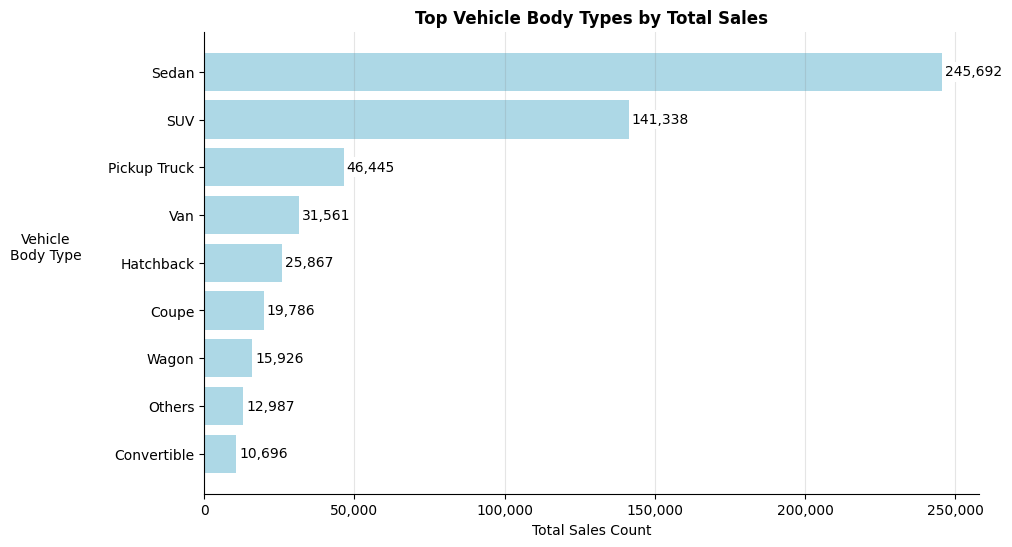

In [6]:
# Q. Which vehicle body types are sold the most?

query = '''
SELECT
    CASE
        WHEN LOWER(body) LIKE '%%sedan%%' THEN 'Sedan'
        WHEN LOWER(body) LIKE '%%navitgation%%' THEN 'Sedan'
        WHEN LOWER(body) LIKE '%%coupe%%' THEN 'Coupe'
        WHEN LOWER(body) LIKE '%%koup%%' THEN 'Coupe'
        WHEN LOWER(body) LIKE '%%cab%%' THEN 'Pickup Truck'
        WHEN LOWER(body) LIKE '%%SuperCrew%%' THEN 'Pickup Truck'
        WHEN LOWER(body) LIKE '%%van%%' THEN 'Van'
        WHEN LOWER(body) LIKE '%%wagon%%' THEN 'Wagon'
        WHEN LOWER(body) LIKE '%%convertible%%' THEN 'Convertible'
        WHEN body LIKE '' THEN 'Others'
        ELSE body
    END AS body_type,
    COUNT(*) AS total_sold
FROM car_sales
GROUP BY body_type
ORDER BY total_sold DESC;
'''

df = pd.read_sql(query, engine)

# Cleaning & Formatting
df["body_type"] = df["body_type"].apply(lambda x: x if x[0].isupper() else x.capitalize())

# Visualization
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(
    df["body_type"],
    df["total_sold"],
    color = "lightblue"
)
for bar, total_sold in zip(bars, df["total_sold"]):
    ax.text(
        bar.get_width() + 1000,
        bar.get_y() + (bar.get_height() / 2),
        f"{total_sold:,}",
        va = "center",
        bbox = dict(
            facecolor = "white",
            edgecolor = "none",
            pad = 2
        )
    )
ax.grid(
    axis = "x",
    color = "grey",
    linestyle = "-",
    alpha = .2
)
ax.set_title(
    "Top Vehicle Body Types by Total Sales",
    fontweight = "bold"
    )
ax.set_xlabel("Total Sales Count")
ax.set_ylabel(
    "Vehicle\nBody Type", 
    rotation = 0,
    labelpad = 45
    )
ticks = range(0, df["total_sold"].max() + 50000, 50000)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{t:,}" for t in ticks])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.invert_yaxis()
plt.show()

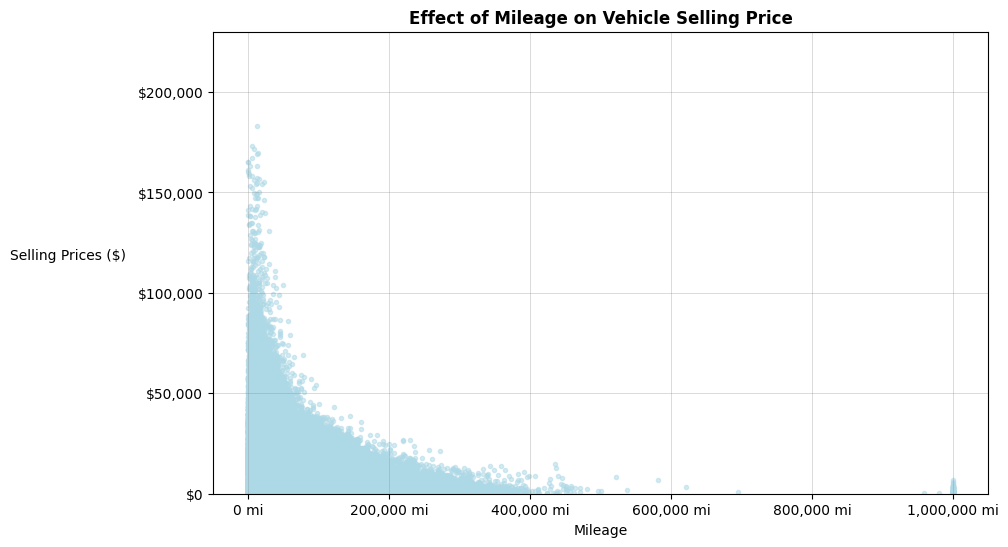

,metric,values
0,lowest price,$0
1,highest price,"$230,000"
2,lowest mileage,0
3,highest mileage,"999,999"


In [7]:
# Q. How does mileage affect selling price?

query = '''
SELECT 
    odometer AS mileage,
    sellingprice AS selling_price,
    mmr
FROM car_sales;
'''

df = pd.read_sql(query, engine)

# Data Exclusion
df[["ratio", "status"]] = df.apply(
    lambda x: get_ratio_status(x["selling_price"], x["mmr"]),
    axis=1,
    result_type="expand"
)
cleaned_df = df[~df["status"].isin(["too_high", "too_low", "invalid"])]

# Visualization
fig, ax = plt.subplots(figsize = (10,6))
ax.scatter(
    cleaned_df["mileage"],
    cleaned_df["selling_price"],
    alpha = .5,
    marker = ".",
    color = "lightblue"
)
ax.set_title(
    "Effect of Mileage on Vehicle Selling Price",
    fontweight = "bold"
    )
ax.set_xlabel("Mileage")
ax.set_ylabel(
    "Selling Prices ($)", 
    rotation = 0,
    labelpad = 50
    )
x_ticks = range(cleaned_df["mileage"].min(), cleaned_df["mileage"].max() + 100000, 200000)
y_tikcs = range(cleaned_df["selling_price"].min(), cleaned_df["selling_price"].max() + 50000, 50000)
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("${x:,.0f}")
)
ax.set_ylim(df["selling_price"].min(), df["selling_price"].max())
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{t:,} mi" for t in x_ticks])
ax.grid(
    axis = "both",
    color = "gray",
    linestyle = "-",
    alpha = .4,
    linewidth = .5
)
    
plt.show()

# Summary
summary = pd.DataFrame({
    "metric": ["lowest price", "highest price", "lowest mileage", "highest mileage"], 
    "values": [f"${df["selling_price"].min():,.0f}", f"${df["selling_price"].max():,.0f}", str(df["mileage"].min()), f"{df["mileage"].max():,.0f}"]
    })

summary

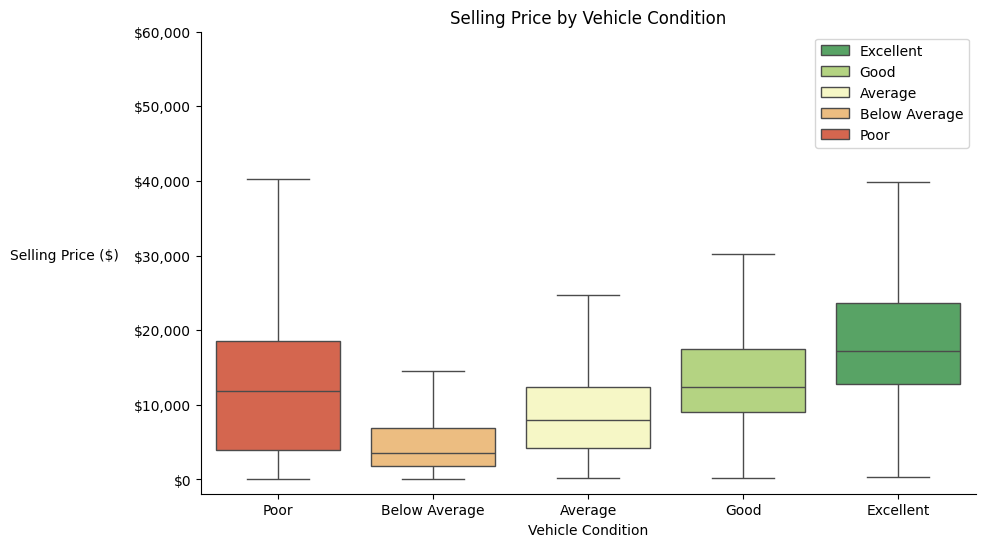

In [8]:
# Q. How does vehicle condition affect selling price?

query = '''
SELECT 
    car_sales.condition AS vehicle_condition,
    sellingprice AS selling_price,
    mmr
FROM car_sales
'''

df = pd.read_sql(query, engine)

# Data Exclusion
df[["ratio", "status"]] = df.apply(
    lambda x: get_ratio_status(x["selling_price"], x["mmr"]),
    axis=1,
    result_type="expand"
)
cleaned_df = df[~df["status"].isin(["too_high", "too_low", "invalid"])]
cleaned_df = categorize_condition(cleaned_df)

# Visualization
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(
    x = "condition_categorized",
    y = "selling_price",
    data = cleaned_df,
    showfliers = False,
    hue = "condition_categorized",
    palette = sns.color_palette("RdYlGn", 5),
    dodge = False
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    loc = "upper right"
    )
ax.set_title("Selling Price by Vehicle Condition")
ax.set_xlabel("Vehicle Condition")
ax.set_ylabel(
    "Selling Price ($)",
    rotation = 0,
    labelpad = 50
    )
ax.set_yticks(range(0, int(cleaned_df["selling_price"].quantile(0.95) + 30000), 10000))
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("${x:,.0f}")
)
sns.despine()

plt.show()

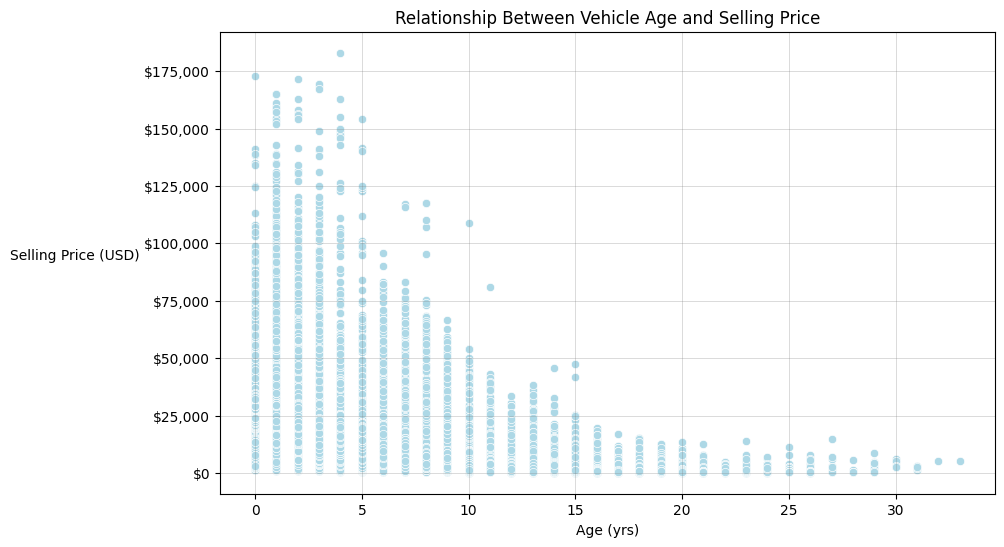

In [9]:
# Q. How does age affect selling price?

query = '''
SELECT 
    year,
    saledate AS sale_year,
    sellingprice AS selling_price,
    mmr
FROM car_sales
'''

df = pd.read_sql(query, engine)

# Data Exclusion
df[["ratio", "status"]] = df.apply(
    lambda x: get_ratio_status(x["selling_price"], x["mmr"]),
    axis=1,
    result_type="expand"
)
cleaned_df = df[~df["status"].isin(["too_high", "too_low", "invalid"])]

# Data Cleaning
cleaned_df["sale_year"] = (
    cleaned_df["sale_year"]
    .str.replace(r" GMT.*", "", regex=True)
    .str.replace(r"\r", "", regex=True)
)
cleaned_df["sale_year"] = cleaned_df["sale_year"].str.extract(r"(\d{4})").astype("Int64")
cleaned_df = cleaned_df[cleaned_df["sale_year"].notna()]
cleaned_df["age"] = cleaned_df["sale_year"] - cleaned_df["year"]
cleaned_df = cleaned_df[cleaned_df["sale_year"] >= 1982]
cleaned_df["age"] = cleaned_df["age"].clip(0)

# Visualization
fig, ax = plt.subplots(figsize = (10,6))
sns.scatterplot(
    x = "age",
    y = "selling_price",
    data = cleaned_df,
    color = "lightblue"
)
ax.grid(
    axis = "both",
    color = "gray",
    linestyle = "-",
    alpha = .4,
    linewidth = .5
)
ax.set_title("Relationship Between Vehicle Age and Selling Price")
ax.set_xlabel("Age (yrs)")
ax.set_ylabel(
    "Selling Price (USD)",
    rotation = 0,
    labelpad = 50
    )
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

plt.show()

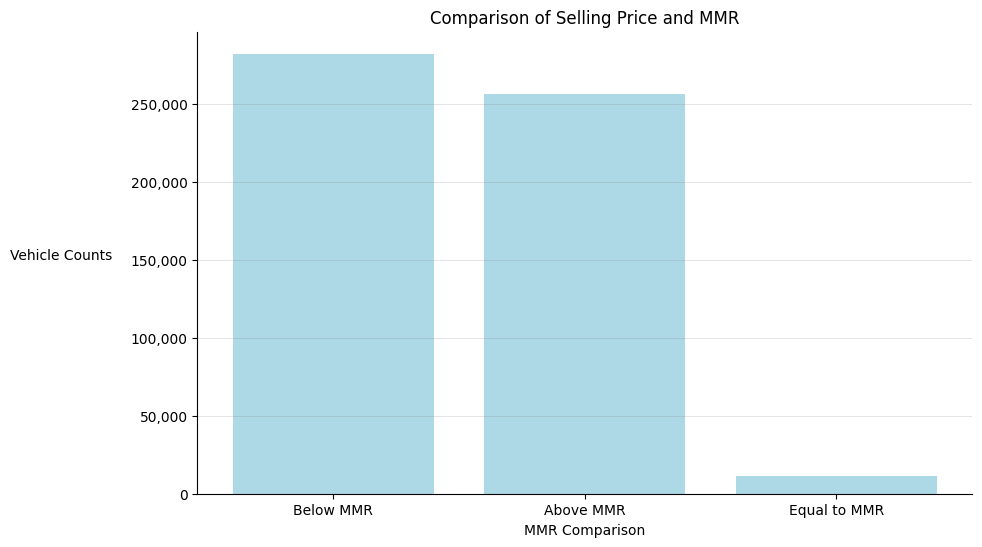

In [10]:
# Are vehicles sold above or below market value (MMR)?

query = '''
SELECT 
    sellingprice AS selling_price,
    mmr
FROM car_sales
'''

df = pd.read_sql(query, engine)

# Data Exclusion
df[["ratio", "status"]] = df.apply(
    lambda x: get_ratio_status(x["selling_price"], x["mmr"]),
    axis = 1,
    result_type = "expand"
)
cleaned_df = df[~df["status"].isin(["too_high", "too_low", "invalid"])]

# Data Cleaning
cleaned_df["mmr_comparison"] = np.where(
    cleaned_df["selling_price"] > cleaned_df["mmr"],
    "Above MMR", 
    np.where(
        cleaned_df["selling_price"] < cleaned_df["mmr"],
        "Below MMR", "Equal to MMR"
        )
    )

# Data Visualization
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(
    cleaned_df["mmr_comparison"].value_counts().index,
    cleaned_df["mmr_comparison"].value_counts().values,
    color = "lightblue"
)
ax.grid(
    axis = "y",
    color = "gray",
    linestyle = "-",
    alpha = .3,
    linewidth = .5
)
ax.set_title("Comparison of Selling Price and MMR")
ax.set_xlabel("MMR Comparison")
ax.set_ylabel(
    "Vehicle Counts",
    rotation = 0,
    labelpad = 50
    )
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

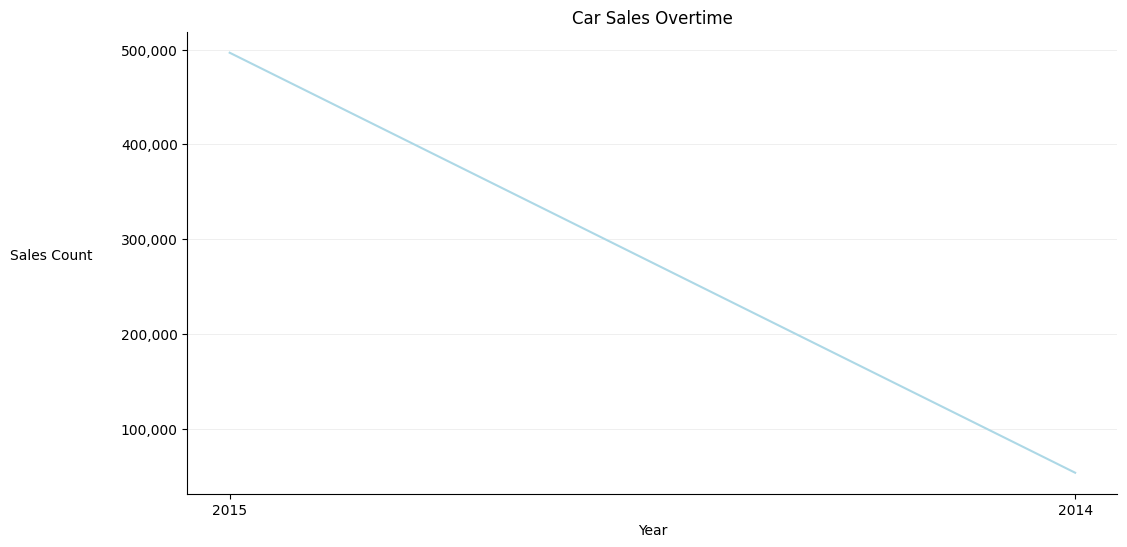

In [11]:
# How do vehicle car sales vary over time?

query = '''
SELECT 
    saledate
FROM car_sales
'''

df = pd.read_sql(query, engine)

# Data Exclusion
mask = df["saledate"].str.contains(
    r"\b[A-Z][a-z]{2} \d{1,2} \d{4}\b",
    na = False
)
cleaned_df = df[mask]
cleaned_df["sale_year"] = cleaned_df["saledate"].str.extract(r"(\d{4})")

# Data Visualization
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(
    cleaned_df["sale_year"].value_counts().index,
    cleaned_df["sale_year"].value_counts().values,
    color = "lightblue"
    )
ax.set_title("Car Sales Overtime")
ax.set_xlabel("Year")
ax.set_ylabel(
    "Sales Count",
    rotation = 0,
    labelpad = 50
    )
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(
    axis = "y",
    linestyle = "-",
    color = "lightgray",
    alpha = .5,
    linewidth = .5
)

plt.show()

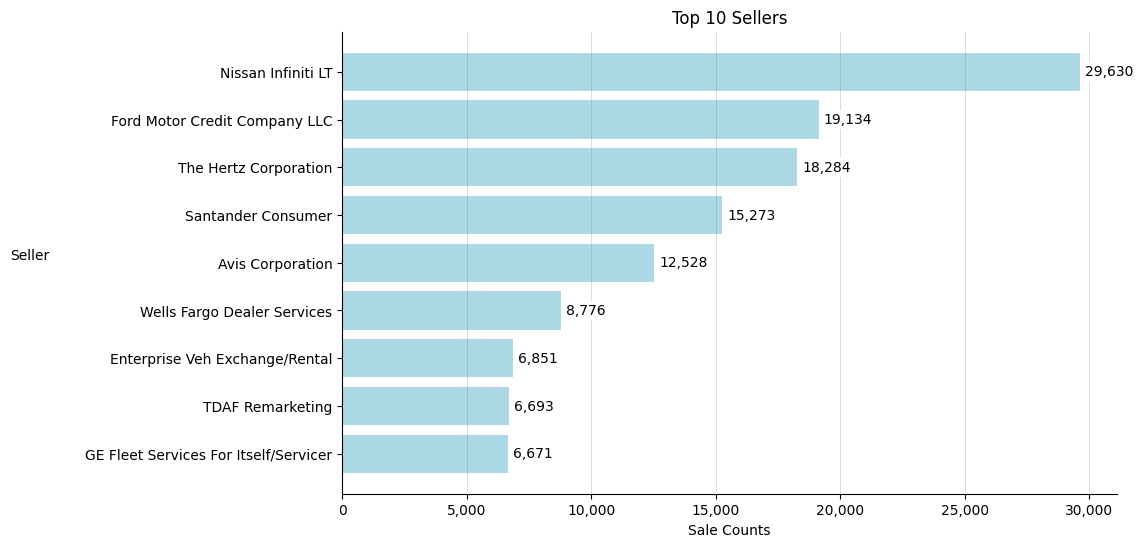

In [12]:
# Which sellers sell the most vehicles?

query = '''
SELECT
	seller,
    COUNT(seller) AS sales_count
FROM car_sales
GROUP BY seller
ORDER BY sales_count DESC
LIMIT 10;
'''

df = pd.read_sql(query, engine)

# Data Cleaning
df = clean_sellers(df)

df = (
        df.groupby("seller", as_index=False)["sales_count"]
        .sum()
        .sort_values("sales_count", ascending=False)
        .reset_index(drop=True)
    )

# Data Visualization
fig, ax = plt.subplots(figsize=(10, 6))
bar = ax.barh(
    df["seller"],
    df["sales_count"],
    color = "lightblue"
)
for bar, sales_count in zip(bar, df["sales_count"]):
    ax.text(
        bar.get_width() + 200,
        bar.get_y() + (bar.get_height() / 2),
        f"{sales_count:,}",
        va = "center",
        bbox = dict(
            facecolor = "white",
            edgecolor = "none",
            pad = 2
        )
    )
ax.set_title("Top 10 Sellers")
ax.set_xlabel(
    "Sale Counts"
)
ax.set_ylabel(
    "Seller",
    rotation = 0,
    labelpad = 40
)
ax.xaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)
ax.grid(
    axis = "x",
    color = "gray",
    linestyle = "-",
    alpha = .4,
    linewidth = .5
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.invert_yaxis()
plt.show()


In [13]:
# Final datasets

# Query
query = """
SELECT *
FROM car_sales;
"""

tableau_df = pd.read_sql(query, engine)

# Data cleaning

# Dropping & renaming columns
tableau_df = tableau_df.drop(["transmission", "trim", "state", "color", "interior"], axis=1)
tableau_df = tableau_df.rename(columns = {"condition" : "vehicle_condition",
                                          "sellingprice": "selling_price",
                                          "saledate": "sale_date",})

# Filling in values
tableau_df[["make", "body", "seller", "model"]] = tableau_df[["make", "body", "seller", "model"]].replace("", np.nan)
tableau_df[["make", "body", "seller", "model"]] = tableau_df[["make", "body", "seller", "model"]].fillna("Unknown")
tableau_df["mmr_comparison"] = np.where(
    tableau_df["selling_price"] > tableau_df["mmr"],
    "Above MMR", 
    np.where(
        tableau_df["selling_price"] < tableau_df["mmr"],
        "Below MMR", "Equal to MMR"
        )
    )

# Categorizes & classifies values
tableau_df = categorize_condition(tableau_df)
tableau_df["body"] = tableau_df["body"].apply(classify_body)
tableau_df["make"] = tableau_df["make"].apply(classify_make)
tableau_df = clean_sellers(tableau_df)

# Formats values
tableau_df["sale_date"] = pd.to_datetime(
    tableau_df["sale_date"],
    errors="coerce"
)
tableau_df["sale_date"] = tableau_df["sale_date"].dt.tz_localize(None)
tableau_df["vehicle_age"] = (tableau_df["sale_date"].dt.year - tableau_df["year"]).astype("Int64")
tableau_df["vehicle_age"] = tableau_df["vehicle_age"].clip(0)
tableau_df["sale_date"] = tableau_df["sale_date"].dt.strftime("%Y%m%d")
tableau_df["sale_date"] = tableau_df["sale_date"].replace("NaT", "")

# Tableau dataset export
tableau_df.to_csv("final_dataset.csv", index=False)

# Line dataset export
tableau_df_line_df = tableau_df[tableau_df["sale_date"].notna() & (tableau_df["sale_date"] != "")]
tableau_df_line_df.to_csv("line_chart_dataset.csv", index=False)

/var/folders/gt/3jng00wn1lddc6wpnv93k4c80000gn/T/ipykernel_79104/3155008306.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tableau_df["sale_date"] = pd.to_datetime(
